# NewsLens — Exploratory Data Analysis

Two datasets:
- **Stock news** (`nasdaq_external_data.parquet`) — 15.5M financial news articles (FNSPID)
- **Stock price** (`stock_price.parquet`) — daily OHLCV for 5,636 tickers

We downsample to the **top 50 tickers** by article count that also have price data.

In [1]:
import os
import re
from pathlib import Path
from collections import Counter

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon', quiet=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

CWD = Path(os.getcwd()).parent
NEWS_PATH  = CWD / 'data' / 'Stock_news' / 'nasdaq_external_data.parquet'
PRICE_PATH = CWD / 'data' / 'Stock_price' / 'stock_price.parquet'

## 1. Dataset Overview

In [2]:
lf_news  = pl.scan_parquet(NEWS_PATH)
lf_price = pl.scan_parquet(PRICE_PATH)

n_news  = lf_news.select(pl.len()).collect().item()
n_price = lf_price.select(pl.len()).collect().item()
price_tickers = lf_price.select('ticker').unique().collect()['ticker'].to_list()

print(f'News rows  : {n_news:>12,}')
print(f'Price rows : {n_price:>12,}')
print(f'Price tickers available: {len(price_tickers):,}')
print()
print('News schema:')
print(lf_news.collect_schema())

News rows  :   15,549,299
Price rows :   18,732,286
Price tickers available: 5,636

News schema:
Schema({'Unnamed: 0': Float64, 'Date': String, 'Article_title': String, 'Stock_symbol': String, 'Url': String, 'Publisher': String, 'Author': String, 'Article': String, 'Lsa_summary': String, 'Luhn_summary': String, 'Textrank_summary': String, 'Lexrank_summary': String})


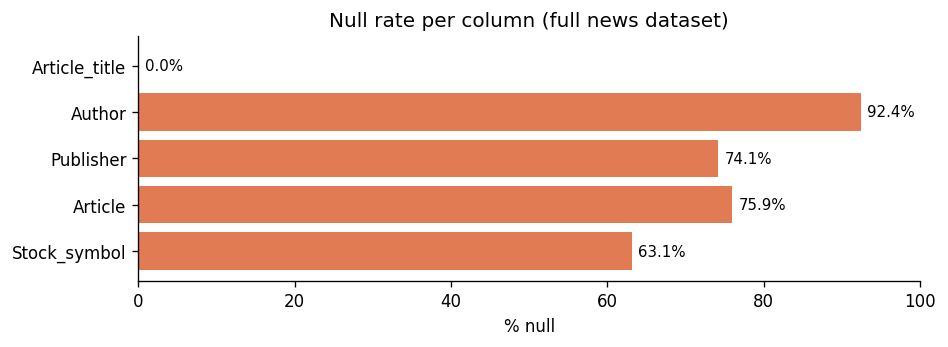

In [3]:
# Null audit on key columns
null_stats = (
    lf_news.select([
        (pl.col(c).is_null().sum() / pl.len() * 100).round(1).alias(c)
        for c in ['Stock_symbol', 'Article', 'Publisher', 'Author', 'Article_title']
    ])
    .collect()
)

cols   = null_stats.columns
pcts   = null_stats.row(0)

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(cols, pcts, color='#e07b54')
ax.bar_label(bars, labels=[f'{v}%' for v in pcts], padding=4, fontsize=9)
ax.set_xlim(0, 100)
ax.set_xlabel('% null')
ax.set_title('Null rate per column (full news dataset)')
plt.tight_layout()
plt.show()

## 2. Ticker Selection — Top 50 by Article Volume

We keep only rows with a non-null `Stock_symbol` **and** a non-null `Article` body,  
then rank by article count and keep tickers that also appear in the price dataset.

In [4]:
# Pool of well-known companies + benchmark ETFs — avoids obscure ETFs/structured products
# that inflate article counts with generic fund descriptions, not real narratives
POOL = [
    # tech
    'AAPL','MSFT','GOOG','GOOGL','AMZN','TSLA','META','NVDA','AMD','INTC','CRM','NFLX',
    'ADBE','PYPL','UBER','SQ','SHOP','ZM','SNAP','COIN','PLTR','ORCL',
    # benchmarks
    'QQQ','SPY','DIA','IWM',
    # telecom
    'T','VZ',
    # banks
    'JPM','GS','MS','WFC','BAC','C',
    # energy
    'XOM','CVX',
    # healthcare
    'JNJ','PFE','MRNA','GILD','MRK','UNH','ABT',
    # retail / consumer
    'WMT','COST','TGT','HD','KO','PEP','SBUX','MCD',
    # industrial
    'BA','GE','CAT','MMM',
    # media
    'DIS','CMCSA',
    # payments
    'V','MA',
    # semis
    'MU','QCOM','TXN','AVGO',
    # auto
    'F','GM',
]

top50_df = (
    lf_news
    .filter(
        pl.col("Stock_symbol").is_in(POOL) &
        pl.col("Article").is_not_null()
    )
    .group_by("Stock_symbol")
    .agg(pl.len().alias("n_articles"))
    .sort("n_articles", descending=True)
    .filter(pl.col("Stock_symbol").is_in(price_tickers))
    .head(50)
    .collect()
)
TOP50 = top50_df["Stock_symbol"].to_list()
print(f"Selected {len(TOP50)} tickers")
print(TOP50)

Selected 29 tickers
['T', 'MSFT', 'GS', 'GOOG', 'TSLA', 'QQQ', 'WFC', 'INTC', 'GE', 'WMT', 'MRK', 'GILD', 'SPY', 'V', 'XOM', 'SBUX', 'MU', 'CRM', 'QCOM', 'ORCL', 'CAT', 'PEP', 'MMM', 'TXN', 'ZM', 'TGT', 'UBER', 'GM', 'SHOP']


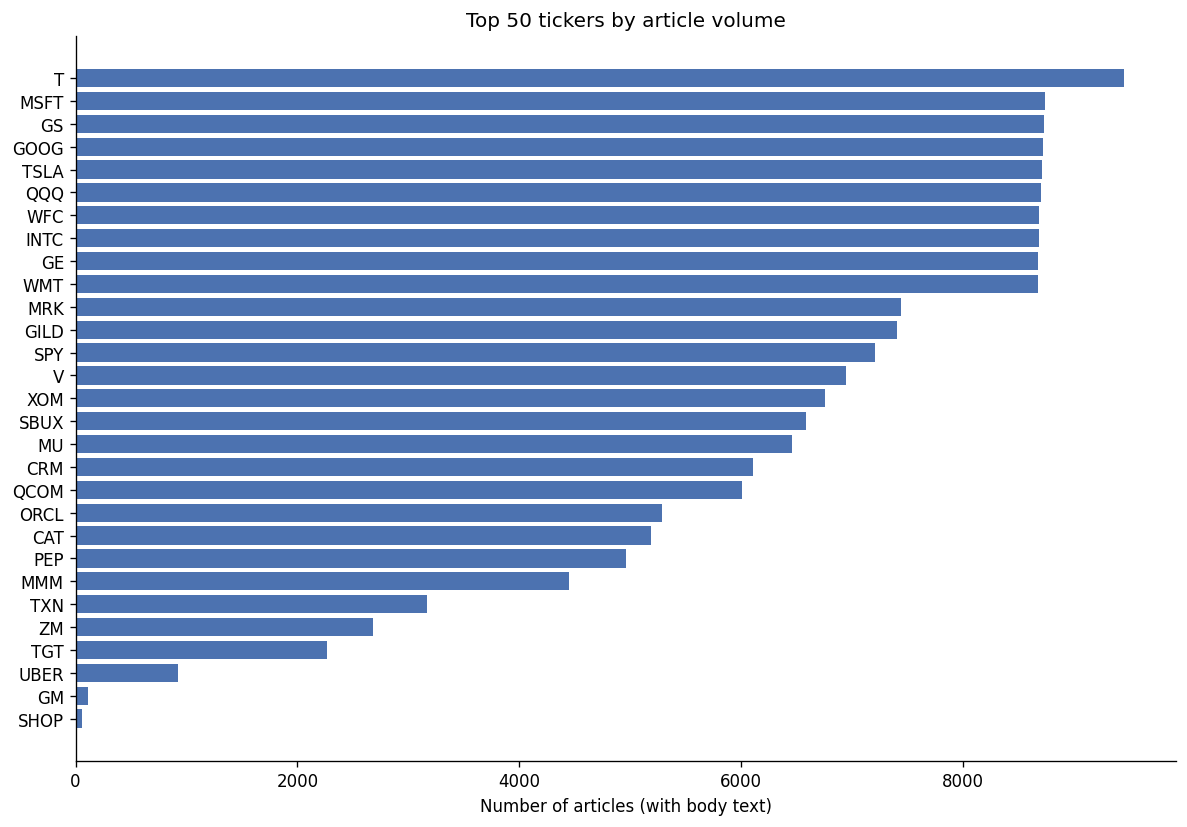

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top50_df['Stock_symbol'].to_list()[::-1],
        top50_df['n_articles'].to_list()[::-1],
        color='#4c72b0')
ax.set_xlabel('Number of articles (with body text)')
ax.set_title('Top 50 tickers by article volume')
plt.tight_layout()
plt.show()

In [6]:
# Collect the filtered subset into memory, drop leftover CSV index
df = (
    lf_news
    .filter(
        pl.col('Stock_symbol').is_in(TOP50) &
        pl.col('Article').is_not_null()
    )
    .drop('Unnamed: 0')
    .with_columns(
        pl.col('Date')
        .str.strptime(pl.Datetime, format='%Y-%m-%d %H:%M:%S UTC', strict=False)
        .dt.date()
        .alias('date_parsed')
    )
    .collect()
)

# Duplicate headline check — exact title matches
dup_titles = (
    df.filter(pl.col('Article_title').is_not_null())
    .group_by('Article_title')
    .agg(pl.len().alias('n'))
    .filter(pl.col('n') > 1)
    .sort('n', descending=True)
)

n_dup_titles = dup_titles['n'].sum() - dup_titles.height  # total extra copies
pct_dup = n_dup_titles / df.height * 100
print(f'Exact duplicate headlines: {n_dup_titles:,} ({pct_dup:.1f}% of subset)')
print(f'Unique duplicate titles: {dup_titles.height:,}')
print('Most repeated headlines:')
print(dup_titles.head(10))

# Remove exact duplicate headlines
df = (
    df.filter(pl.col('Article_title').is_not_null())
    .unique(subset='Article_title', keep='first')
)

print(f'Subset shape: {df.shape}')

Exact duplicate headlines: 38,275 (21.5% of subset)
Unique duplicate titles: 22,909
Most repeated headlines:
shape: (10, 2)
┌─────────────────────────────────┬─────┐
│ Article_title                   ┆ n   │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ What Happened in the Stock Mar… ┆ 96  │
│ Guru Fundamental Report for TS… ┆ 84  │
│ 5 Dividend Aristocrats Where A… ┆ 74  │
│ 3 Things to Watch in the Stock… ┆ 65  │
│ Guru Fundamental Report for QC… ┆ 64  │
│ Guru Fundamental Report for CR… ┆ 62  │
│ 5 Dividend Growth Stocks With … ┆ 56  │
│ Guru Fundamental Report for OR… ┆ 56  │
│ Guru Fundamental Report for WM… ┆ 55  │
│ Guru Fundamental Report for MU  ┆ 54  │
└─────────────────────────────────┴─────┘
Subset shape: (139522, 12)


In [7]:
if os.path.exists(os.path.join(CWD, 'data', 'Stock_news', 'subset_news.parquet')):
    print('Subset file already exists, skipping write.')
else:
    df.write_parquet(os.path.join(CWD, 'data', 'Stock_news', 'subset_news.parquet'))
    print('Subset saved to data/Stock_news/subset_news.parquet')

Subset saved to data/Stock_news/subset_news.parquet


## 3. Temporal Coverage

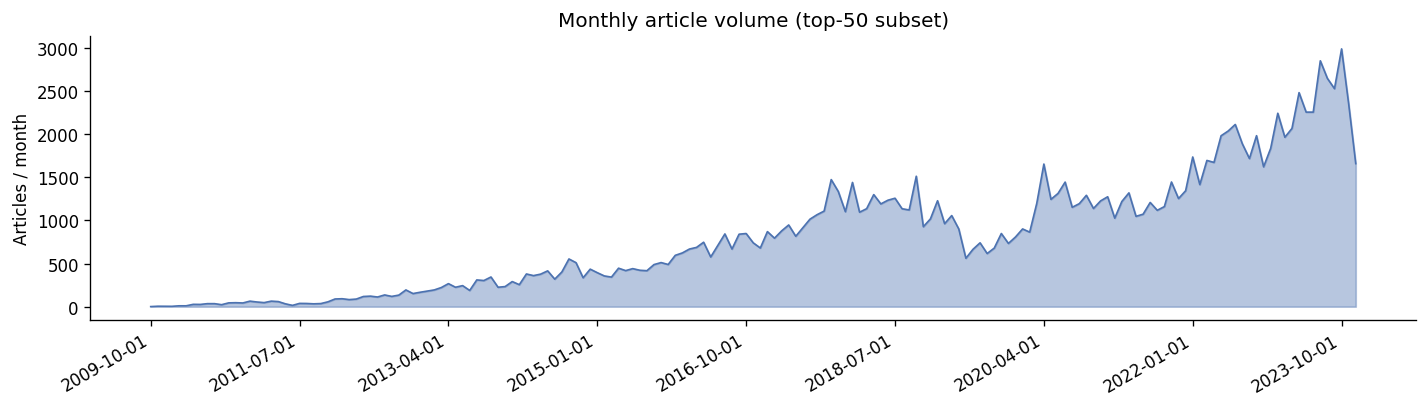

In [8]:
# Monthly article volume
monthly = (
    df.filter(pl.col('date_parsed').is_not_null())
    .with_columns(pl.col('date_parsed').dt.truncate('1mo').alias('month'))
    .group_by('month').agg(pl.len().alias('n'))
    .sort('month')
)

months = monthly['month'].to_list()
counts = monthly['n'].to_list()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(range(len(months)), counts, alpha=0.4, color='#4c72b0')
ax.plot(range(len(months)), counts, lw=1, color='#4c72b0')
step = max(1, len(months) // 8)
ax.set_xticks(range(0, len(months), step))
ax.set_xticklabels([str(months[i]) for i in range(0, len(months), step)], rotation=30, ha='right')
ax.set_ylabel('Articles / month')
ax.set_title('Monthly article volume (top-50 subset)')
plt.tight_layout()
plt.show()

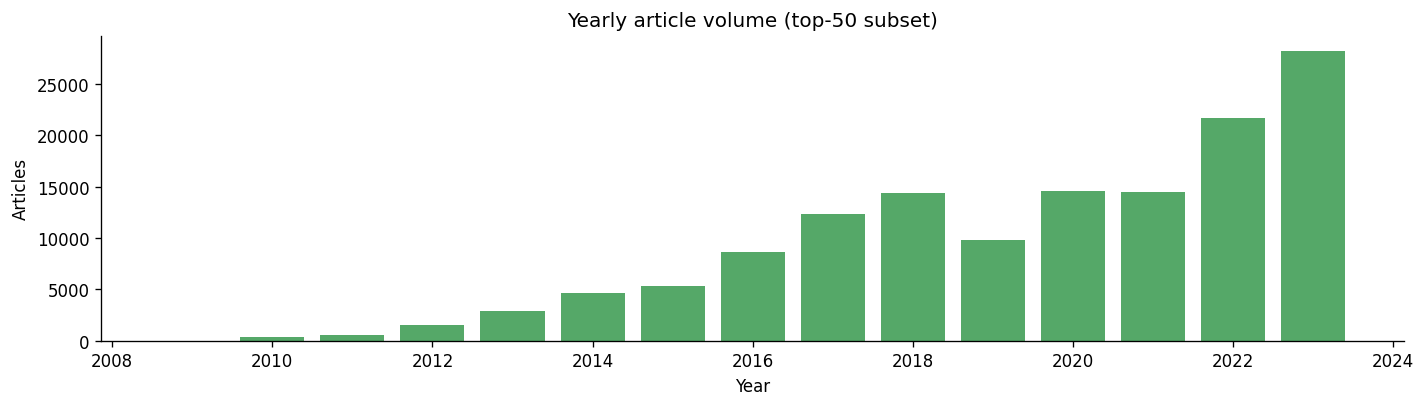

In [9]:
# Yearly article count — check for temporal gaps
yearly = (
    df.filter(pl.col('date_parsed').is_not_null())
    .with_columns(pl.col('date_parsed').dt.year().alias('year'))
    .group_by('year').agg(pl.len().alias('n'))
    .sort('year')
)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(yearly['year'].to_list(), yearly['n'].to_list(), color='#55a868')
ax.set_xlabel('Year')
ax.set_ylabel('Articles')
ax.set_title('Yearly article volume (top-50 subset)')
plt.tight_layout()
plt.show()

## 4. Publisher Distribution

In [10]:
(
    df.filter(pl.col('Publisher').is_not_null())
)

# There are no publishers in this subet

Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary,date_parsed
str,str,str,str,str,str,str,str,str,str,str,date


In [11]:
# pub = (
#     df.filter(pl.col('Publisher').is_not_null())
#     .group_by('Publisher').agg(pl.len().alias('n'))
#     .sort('n', descending=True).head(15)
# )

# fig, ax = plt.subplots(figsize=(9, 5))
# ax.barh(pub['Publisher'].to_list()[::-1], pub['n'].to_list()[::-1], color='#55a868')
# ax.set_xlabel('Article count')
# ax.set_title('Top 15 publishers (top-50 subset)')
# plt.tight_layout()
# plt.show()

## 5. Article Text Statistics

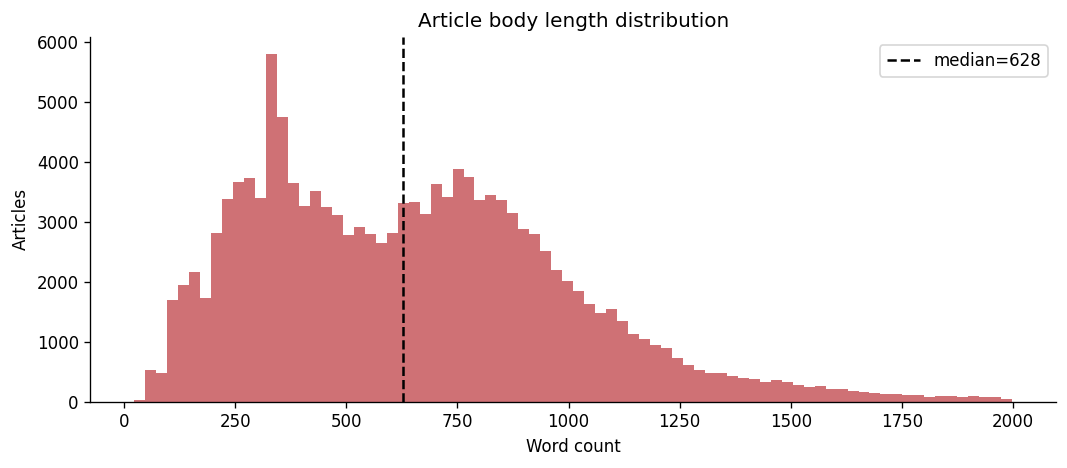

In [12]:
# Word count distribution of article body
wc = (
    df.with_columns(
        pl.col('Article').str.split(' ').list.len().alias('word_count')
    )
    .filter(pl.col('word_count') < 2000)  # remove extreme outliers for viz
    ['word_count'].to_list()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(wc, bins=80, color='#c44e52', edgecolor='none', alpha=0.8)
ax.axvline(np.median(wc), color='k', linestyle='--', lw=1.5, label=f'median={int(np.median(wc))}')
ax.set_xlabel('Word count')
ax.set_ylabel('Articles')
ax.set_title('Article body length distribution')
ax.legend()
plt.tight_layout()
plt.show()

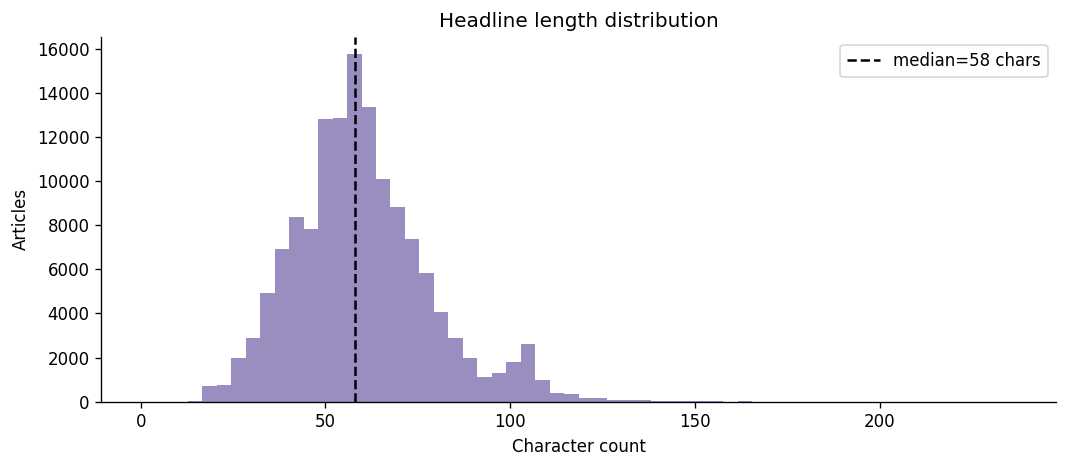

In [13]:
# Headline character length
hl = (
    df.filter(pl.col('Article_title').is_not_null())
    .with_columns(pl.col('Article_title').str.len_chars().alias('title_len'))
    ['title_len'].to_list()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(hl, bins=60, color='#8172b2', edgecolor='none', alpha=0.8)
ax.axvline(np.median(hl), color='k', linestyle='--', lw=1.5, label=f'median={int(np.median(hl))} chars')
ax.set_xlabel('Character count')
ax.set_ylabel('Articles')
ax.set_title('Headline length distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Market Price — EDA

In [14]:
# Load price data for the top-50 tickers
df_price = (
    lf_price
    .filter(pl.col('ticker').is_in(TOP50))
    .with_columns(
        pl.col('date').str.strptime(pl.Date, format='%Y-%m-%d', strict=False)
    )
    .sort(['ticker', 'date'])
    .collect()
)
print(f'Price subset shape: {df_price.shape}')

Price subset shape: (245996, 8)


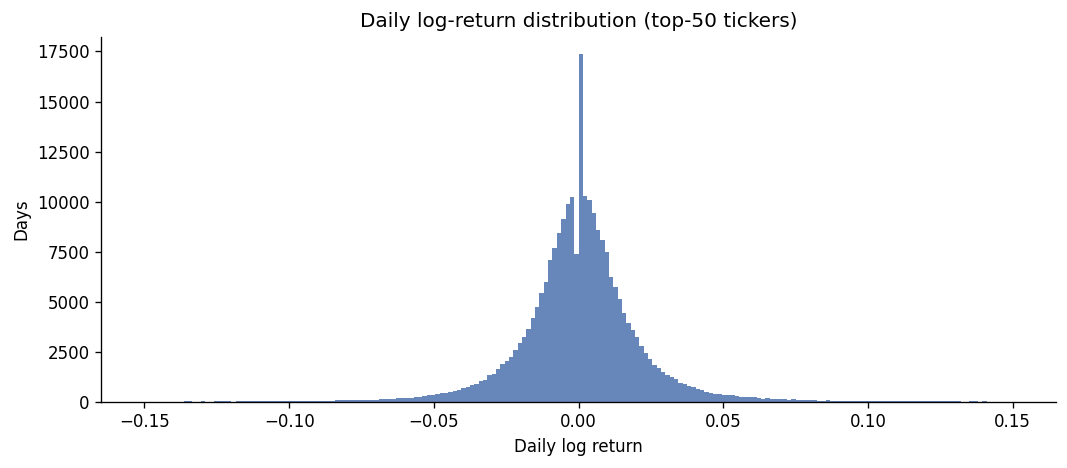

In [15]:
# Daily log-return distribution across all top-50 tickers
df_returns = (
    df_price
    .with_columns(
        (pl.col('close') / pl.col('close').shift(1).over('ticker')).log().alias('log_ret')
    )
    .filter(pl.col('log_ret').is_not_null() & pl.col('log_ret').is_finite())
)

rets = df_returns['log_ret'].to_list()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rets, bins=200, range=(-0.15, 0.15), color='#4c72b0', edgecolor='none', alpha=0.85)
ax.set_xlabel('Daily log return')
ax.set_ylabel('Days')
ax.set_title('Daily log-return distribution (top-50 tickers)')
plt.tight_layout()
plt.show()

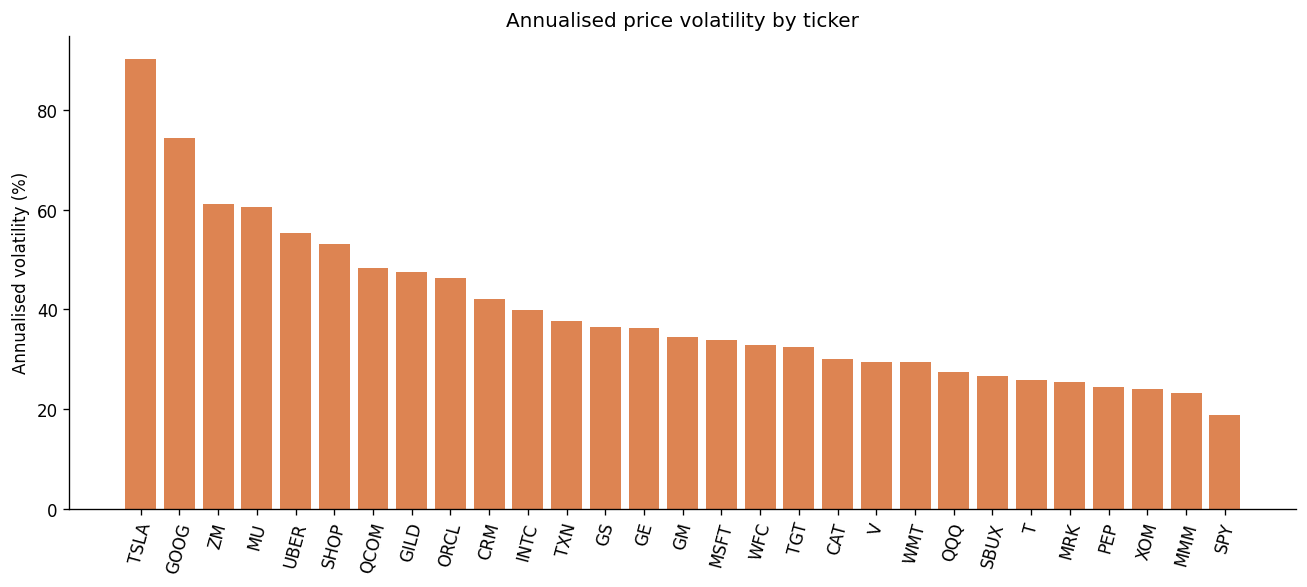

In [16]:
# Annualised volatility per ticker (std of daily log returns × √252)
vol = (
    df_returns
    .group_by('ticker')
    .agg((pl.col('log_ret').std() * (252 ** 0.5) * 100).alias('ann_vol_pct'))
    .sort('ann_vol_pct', descending=True)
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(vol['ticker'].to_list(), vol['ann_vol_pct'].to_list(), color='#dd8452')
ax.set_ylabel('Annualised volatility (%)')
ax.set_title('Annualised price volatility by ticker')
ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

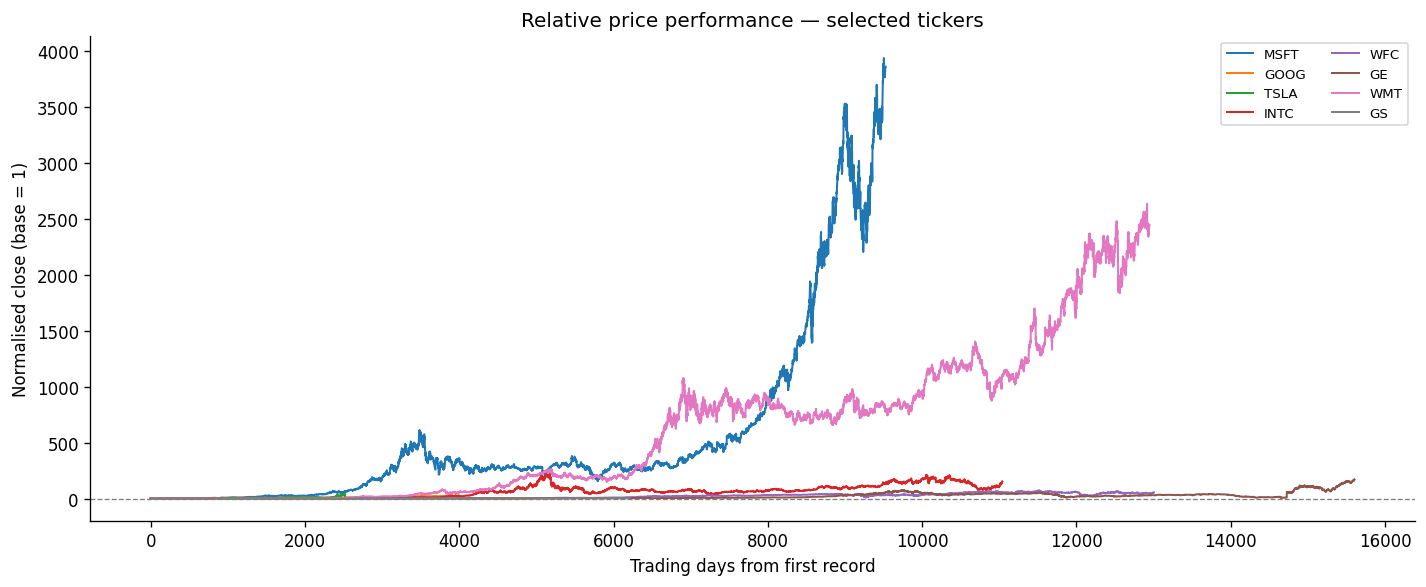

In [17]:
# Normalised close price for a handful of well-known tickers
WATCH = [t for t in ['MSFT', 'GOOG', 'TSLA', 'INTC', 'WFC', 'GE', 'WMT', 'GS'] if t in TOP50]

fig, ax = plt.subplots(figsize=(12, 5))
for ticker in WATCH:
    sub = df_price.filter(pl.col('ticker') == ticker).sort('date')
    prices = sub['close'].to_list()
    dates  = list(range(len(prices)))
    if prices[0] and prices[0] != 0:
        norm = [p / prices[0] for p in prices]
        ax.plot(dates, norm, lw=1.2, label=ticker)

ax.axhline(1, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel('Trading days from first record')
ax.set_ylabel('Normalised close (base = 1)')
ax.set_title('Relative price performance — selected tickers')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Movement label feasibility (FinBERT Head 3)

The future-movement head needs binary labels: **1** if close price moves ≥ ±1.5% within 3 days of article publication, **0** otherwise. How balanced is this label?

Label 0:   75,001  (30.5%)
Label 1:  170,966  (69.5%)


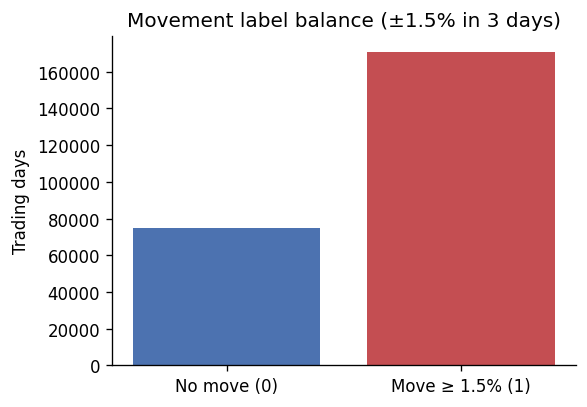

In [18]:
# Compute max absolute return in the 3 days following each trading day
THRESHOLD = 0.015

df_fwd = (
    df_price
    .sort(['ticker', 'date'])
    .with_columns([
        (pl.col('close').shift(-i).over('ticker') / pl.col('close') - 1).abs().alias(f'ret_d{i}')
        for i in range(1, 4)
    ])
    .with_columns(
        pl.max_horizontal('ret_d1', 'ret_d2', 'ret_d3').alias('max_3d_abs_ret')
    )
    .with_columns(
        (pl.col('max_3d_abs_ret') >= THRESHOLD).cast(pl.Int8).alias('move_label')
    )
    .filter(pl.col('move_label').is_not_null())
)

label_counts = df_fwd.group_by('move_label').agg(pl.len().alias('n')).sort('move_label')
total = label_counts['n'].sum()
for row in label_counts.iter_rows():
    print(f'Label {row[0]}: {row[1]:>8,}  ({row[1]/total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['No move (0)', 'Move ≥ 1.5% (1)'], label_counts['n'].to_list(), color=['#4c72b0', '#c44e52'])
ax.set_ylabel('Trading days')
ax.set_title(f'Movement label balance (±{THRESHOLD*100:.1f}% in 3 days)')
plt.tight_layout()
plt.show()

## 7. Bag-of-Words — Top Terms per Ticker

We use article **headlines** (shorter, cleaner) and a standard `CountVectorizer` with stop-word removal.

In [19]:
# Basic text cleaner: lowercase, remove punctuation
def clean(text):
    return re.sub(r'[^a-z\s]', ' ', text.lower())

BOW_TICKERS = [t for t in ['MSFT', 'GOOG', 'TSLA', 'INTC', 'WFC', 'GE', 'WMT', 'GS', 'QQQ', 'T'] if t in TOP50]

bow_data = (
    df.filter(pl.col('Stock_symbol').is_in(BOW_TICKERS) & pl.col('Article_title').is_not_null())
    .select(['Stock_symbol', 'Article_title'])
)
print(f'{bow_data.shape[0]:,} headlines across {len(BOW_TICKERS)} tickers')

69,476 headlines across 10 tickers


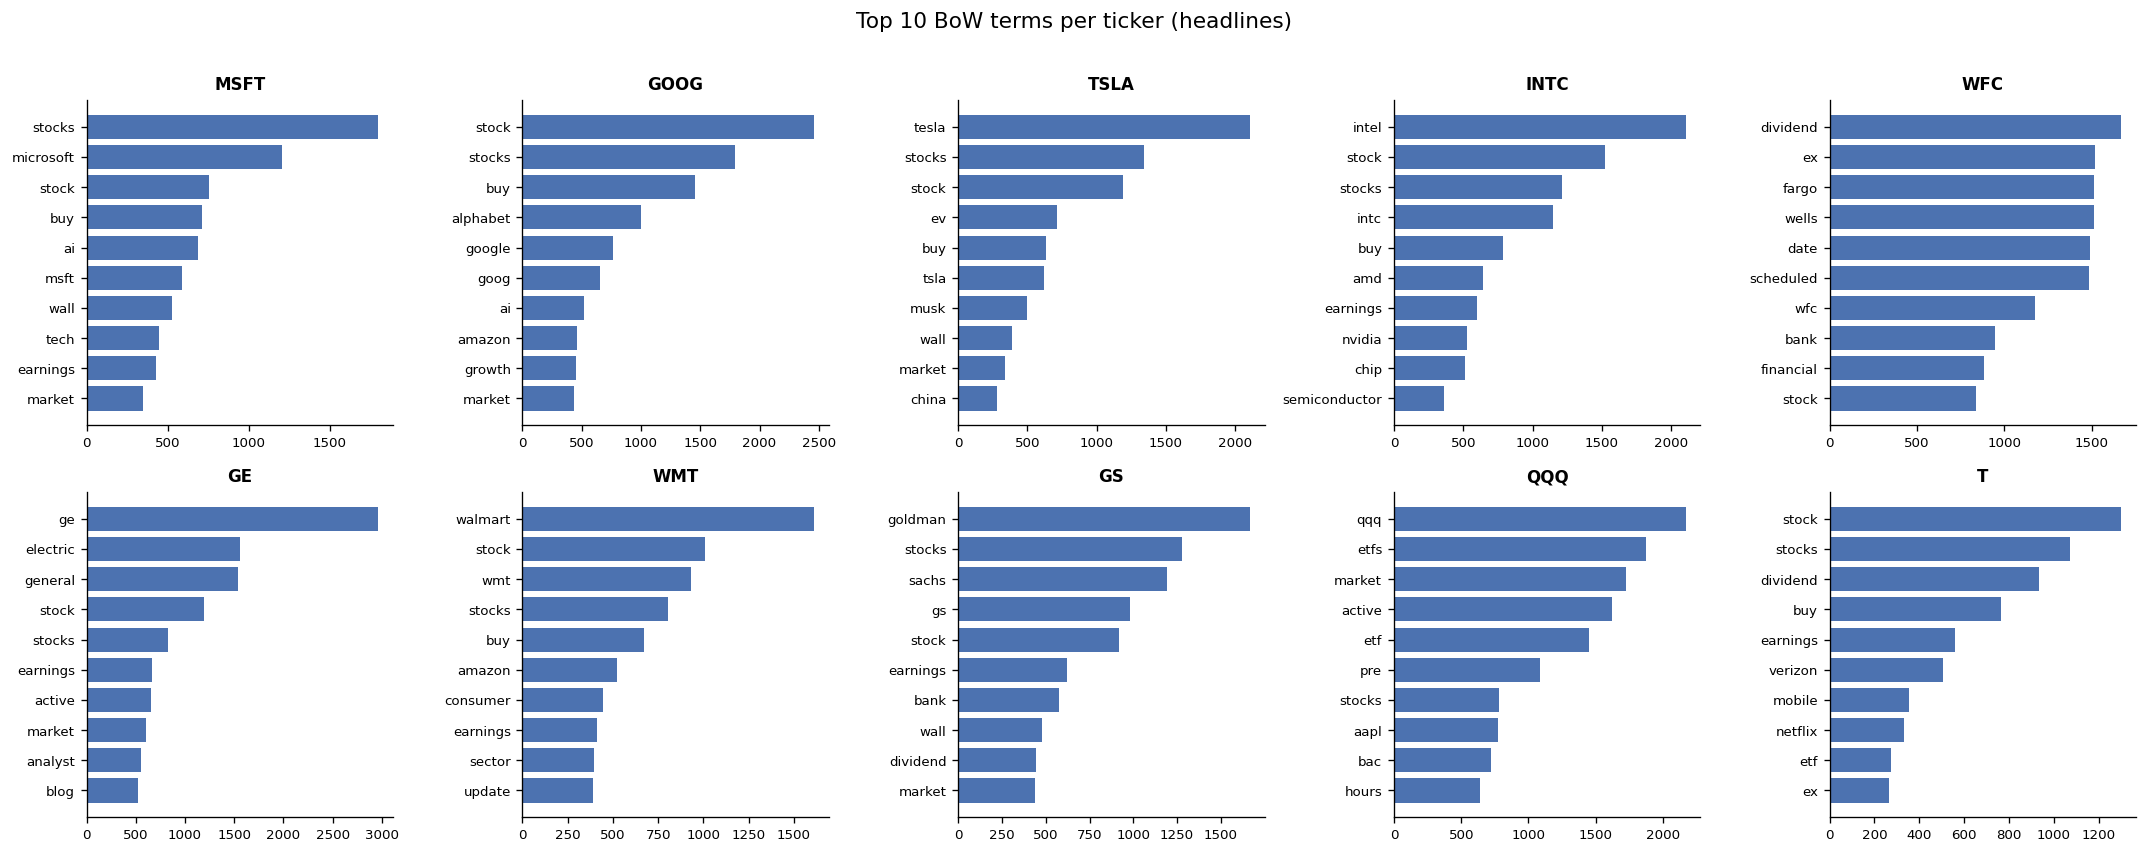

In [20]:
# BoW top-10 words per ticker subplot
vectorizer = CountVectorizer(stop_words='english', max_features=2000, min_df=2)

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for i, ticker in enumerate(BOW_TICKERS[:10]):
    texts = [
        clean(t) for t in
        bow_data.filter(pl.col('Stock_symbol') == ticker)['Article_title'].to_list()
    ]
    if len(texts) < 5:
        continue
    X = vectorizer.fit_transform(texts)
    freq = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))
    top10 = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:10]
    words, cnts = zip(*top10)

    axes[i].barh(list(words)[::-1], list(cnts)[::-1], color='#4c72b0')
    axes[i].set_title(ticker, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Top 10 BoW terms per ticker (headlines)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. TF-IDF — Distinctive Terms per Ticker

Unlike raw counts, TF-IDF down-weights terms that appear across all tickers, surfacing  
what is **distinctive** about each ticker's coverage.

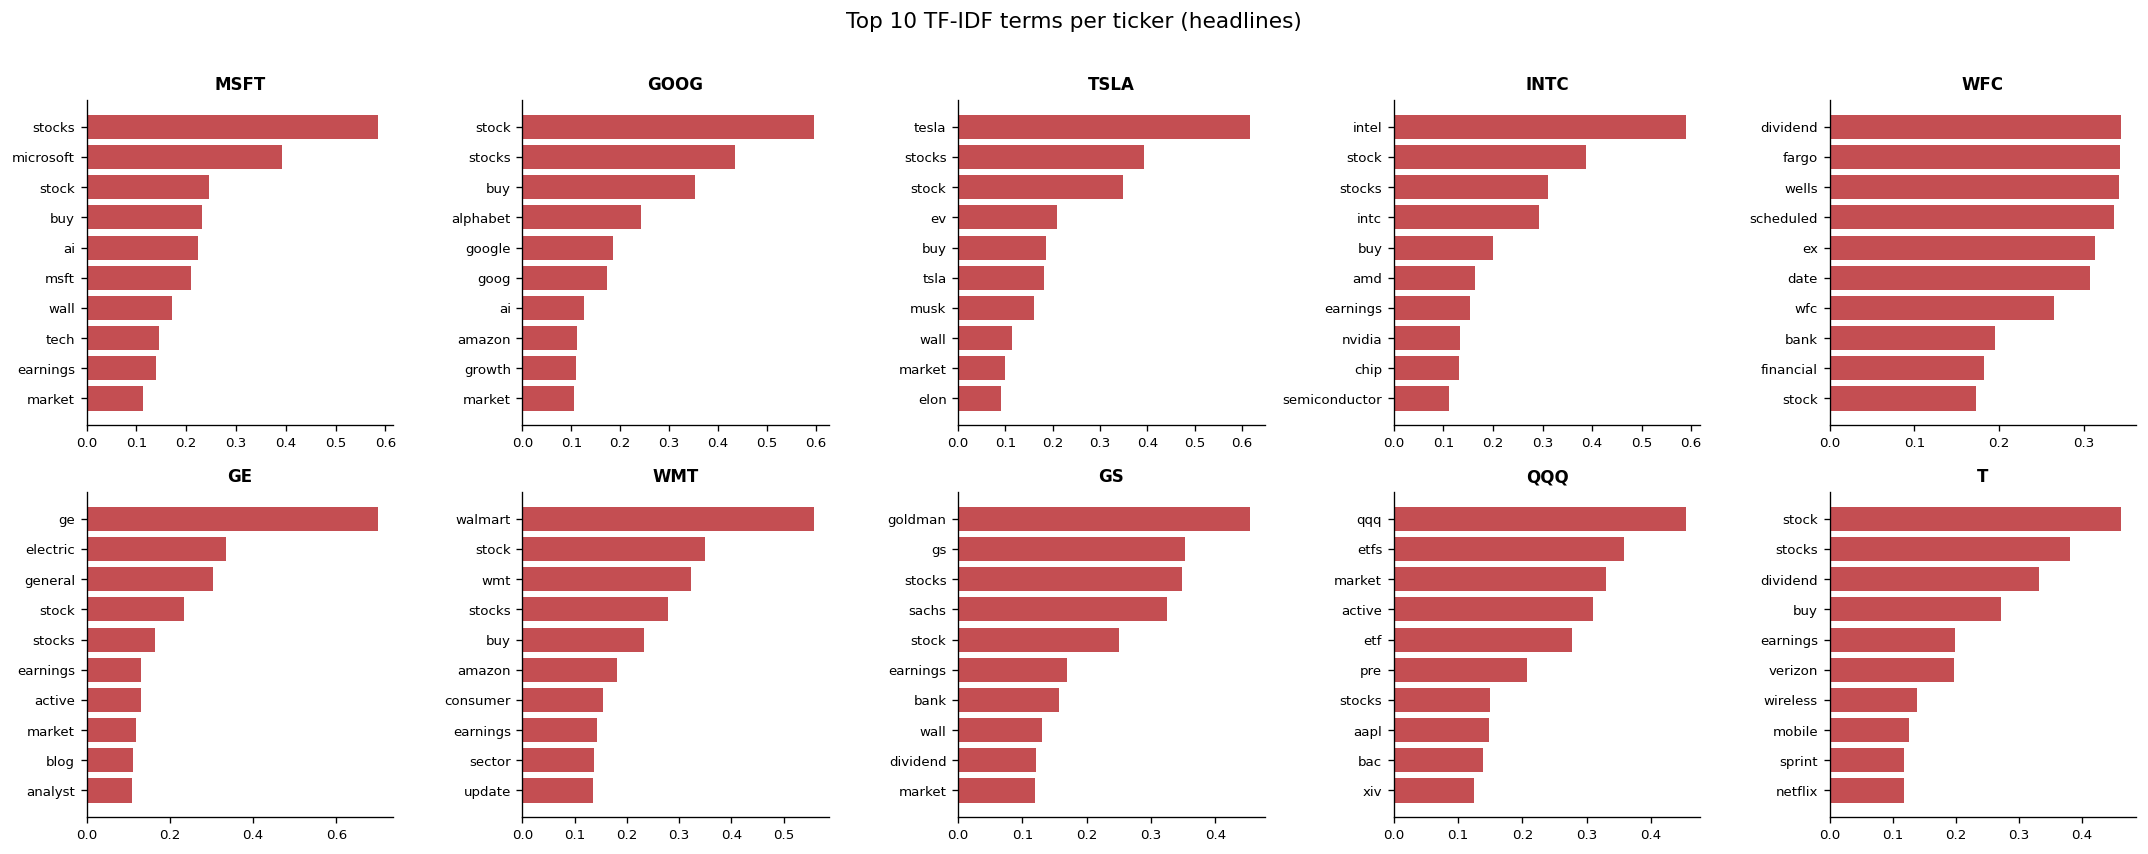

In [21]:
# One document per ticker = concatenated headlines
ticker_docs = {
    ticker: ' '.join([
        clean(t) for t in
        bow_data.filter(pl.col('Stock_symbol') == ticker)['Article_title'].to_list()
    ])
    for ticker in BOW_TICKERS
}

tickers_list = list(ticker_docs.keys())
corpus       = list(ticker_docs.values())

tfidf = TfidfVectorizer(stop_words='english', max_features=3000, min_df=1)
X_tfidf = tfidf.fit_transform(corpus)
vocab   = tfidf.get_feature_names_out()

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for i, ticker in enumerate(tickers_list[:10]):
    scores = X_tfidf[i].toarray().flatten()
    top_idx = scores.argsort()[-10:][::-1]
    words = [vocab[j] for j in top_idx]
    vals  = [scores[j] for j in top_idx]

    axes[i].barh(words[::-1], vals[::-1], color='#c44e52')
    axes[i].set_title(ticker, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Top 10 TF-IDF terms per ticker (headlines)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Baseline Sentiment — VADER

VADER is a lexicon-based scorer built for short, informal text.  
We apply it to headlines as a quick sentiment baseline before training FinBERT.

In [22]:
# Score a random sample of 5k headlines to stay fast
sia = SentimentIntensityAnalyzer()

sample = (
    df.filter(pl.col('Article_title').is_not_null() & pl.col('Stock_symbol').is_in(BOW_TICKERS))
    .sample(n=5000, seed=42)
    .select(['Stock_symbol', 'Article_title'])
)

# compound score: -1 (very negative) → +1 (very positive)
scores = [sia.polarity_scores(t)['compound'] for t in sample['Article_title'].to_list()]
sample = sample.with_columns(pl.Series('vader_compound', scores))

print(sample.group_by('Stock_symbol')
      .agg(pl.col('vader_compound').mean().round(3).alias('mean_sentiment'))
      .sort('mean_sentiment', descending=True))

shape: (10, 2)
┌──────────────┬────────────────┐
│ Stock_symbol ┆ mean_sentiment │
│ ---          ┆ ---            │
│ str          ┆ f64            │
╞══════════════╪════════════════╡
│ QQQ          ┆ 0.153          │
│ GE           ┆ 0.134          │
│ GOOG         ┆ 0.117          │
│ WMT          ┆ 0.112          │
│ MSFT         ┆ 0.104          │
│ INTC         ┆ 0.099          │
│ WFC          ┆ 0.097          │
│ TSLA         ┆ 0.072          │
│ T            ┆ 0.067          │
│ GS           ┆ 0.04           │
└──────────────┴────────────────┘


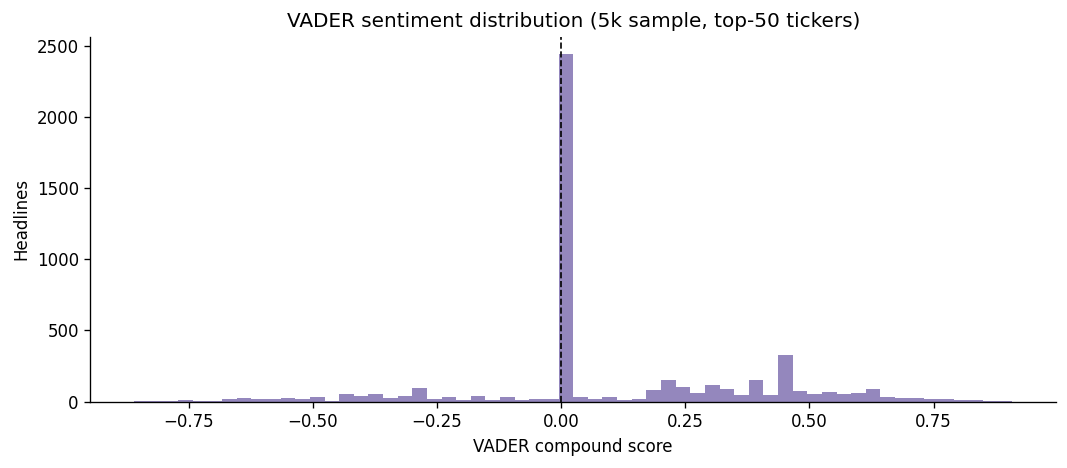

In [23]:
# Overall VADER compound distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores, bins=60, color='#8172b2', edgecolor='none', alpha=0.85)
ax.axvline(0, color='k', lw=1, linestyle='--')
ax.set_xlabel('VADER compound score')
ax.set_ylabel('Headlines')
ax.set_title('VADER sentiment distribution (5k sample, top-50 tickers)')
plt.tight_layout()
plt.show()

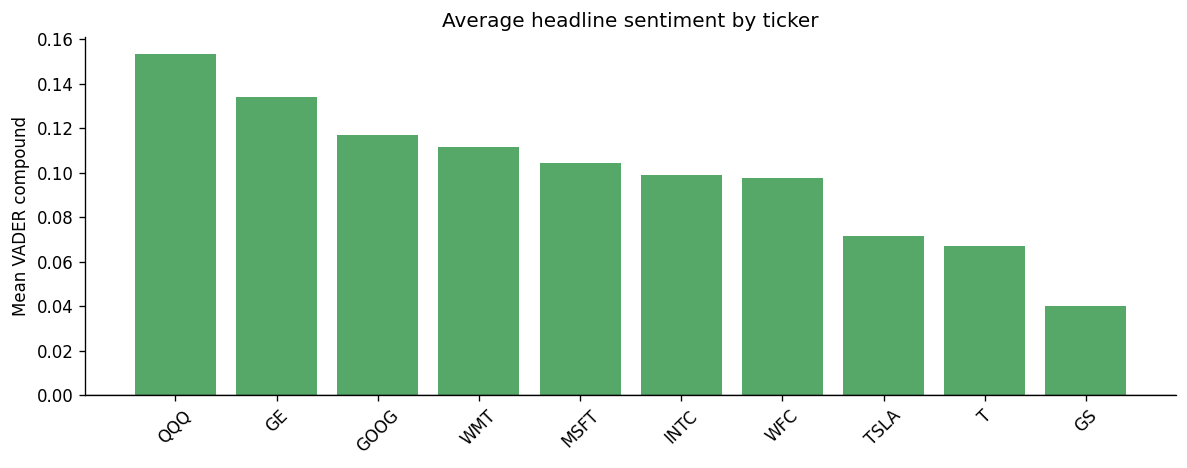

In [24]:
# Average VADER sentiment per ticker
sent_by_ticker = (
    sample.group_by('Stock_symbol')
    .agg(pl.col('vader_compound').mean().alias('mean_sent'))
    .sort('mean_sent', descending=True)
)

colors = ['#55a868' if v >= 0 else '#c44e52' for v in sent_by_ticker['mean_sent'].to_list()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(sent_by_ticker['Stock_symbol'].to_list(),
       sent_by_ticker['mean_sent'].to_list(),
       color=colors)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('Mean VADER compound')
ax.set_title('Average headline sentiment by ticker')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 10. Cross-Dataset Signal — News Volume × Volatility

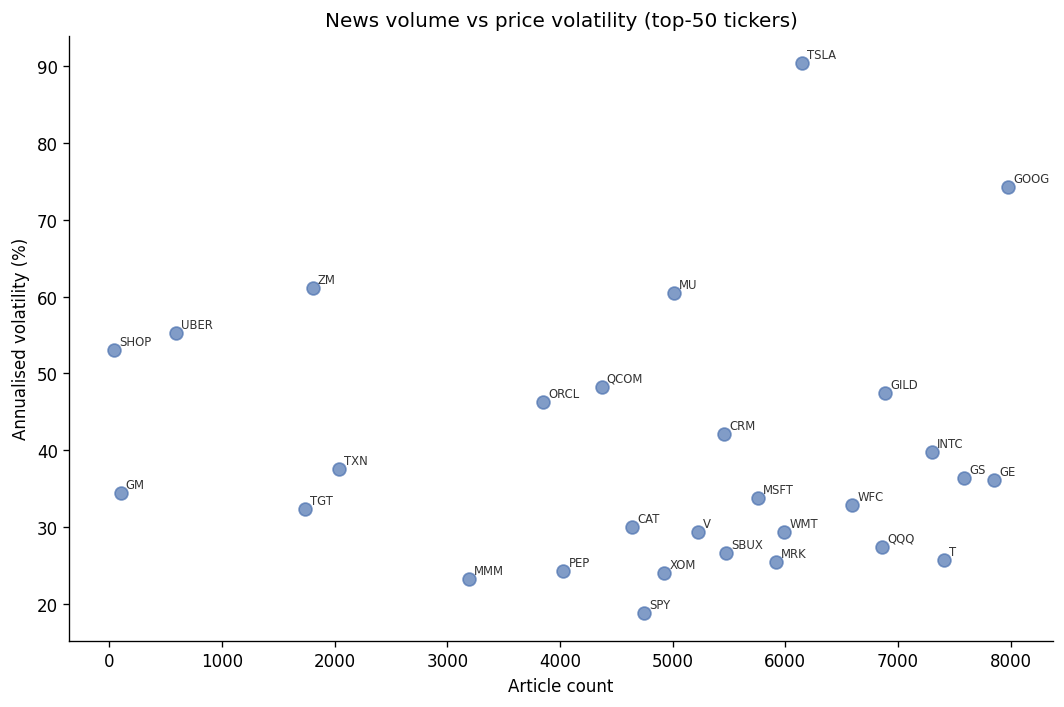

In [25]:
# Scatter: article count vs annualised volatility
art_cnt = (
    df.filter(pl.col('Stock_symbol').is_in(TOP50))
    .group_by('Stock_symbol')
    .agg(pl.len().alias('n_art'))
)

# merge with volatility computed earlier
scatter_df = art_cnt.join(
    vol.rename({'ticker': 'Stock_symbol'}), on='Stock_symbol', how='inner'
)

x = scatter_df['n_art'].to_list()
y = scatter_df['ann_vol_pct'].to_list()
labels = scatter_df['Stock_symbol'].to_list()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, s=60, alpha=0.7, color='#4c72b0')
for xi, yi, lab in zip(x, y, labels):
    ax.annotate(lab, (xi, yi), fontsize=7, alpha=0.8,
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Article count')
ax.set_ylabel('Annualised volatility (%)')
ax.set_title('News volume vs price volatility (top-50 tickers)')
plt.tight_layout()
plt.show()

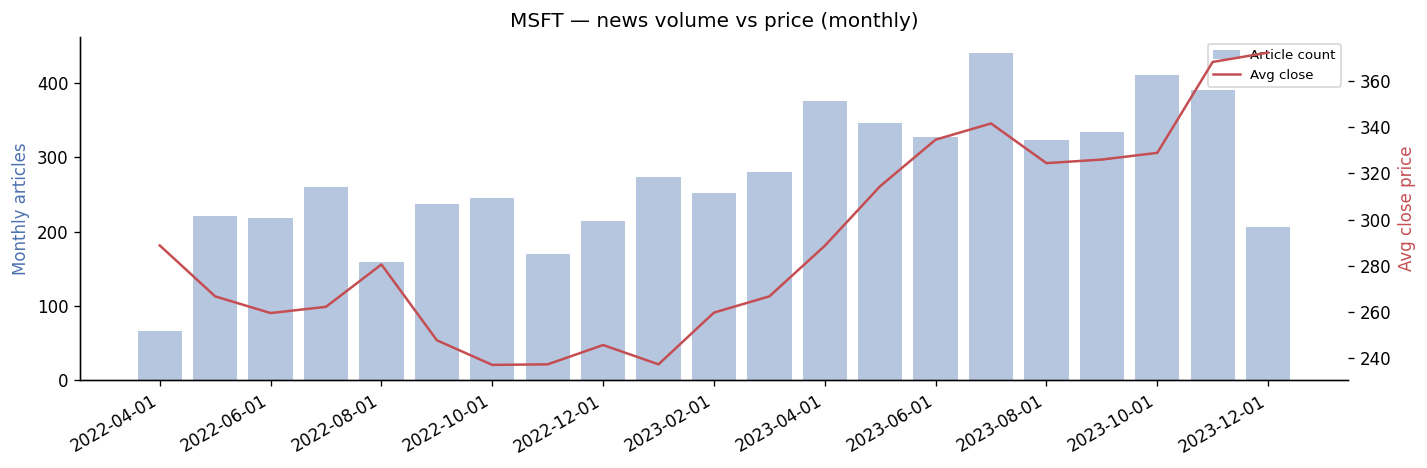

In [26]:
# Monthly news volume vs close price for MSFT (or first available well-known ticker)
FOCUS = next((t for t in ['MSFT', 'GOOG', 'TSLA', 'INTC', 'GS'] if t in TOP50), TOP50[0])

# news monthly counts
news_m = (
    df.filter(pl.col('Stock_symbol') == FOCUS)
    .filter(pl.col('date_parsed').is_not_null())
    .with_columns(pl.col('date_parsed').dt.truncate('1mo').alias('month'))
    .group_by('month').agg(pl.len().alias('n_news'))
    .sort('month')
)

# price monthly avg close
price_m = (
    df_price.filter(pl.col('ticker') == FOCUS)
    .with_columns(pl.col('date').dt.truncate('1mo').alias('month'))
    .group_by('month').agg(pl.col('close').mean().alias('avg_close'))
    .sort('month')
)

aligned = news_m.join(price_m, on='month', how='inner').sort('month')

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

months_a = list(range(len(aligned)))
ax1.bar(months_a, aligned['n_news'].to_list(), alpha=0.4, color='#4c72b0', label='Article count')
ax2.plot(months_a, aligned['avg_close'].to_list(), color='#c44e52', lw=1.5, label='Avg close')

step = max(1, len(months_a) // 8)
ax1.set_xticks(range(0, len(months_a), step))
ax1.set_xticklabels([str(aligned['month'].to_list()[i]) for i in range(0, len(months_a), step)],
                    rotation=30, ha='right')
ax1.set_ylabel('Monthly articles', color='#4c72b0')
ax2.set_ylabel('Avg close price', color='#c44e52')
ax1.set_title(f'{FOCUS} — news volume vs price (monthly)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
plt.tight_layout()
plt.show()

In [27]:
df.head()

Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary,date_parsed
str,str,str,str,str,str,str,str,str,str,str,date
"""2023-08-17 00:00:00 UTC""","""Biotech Stock Roundup: GLTO Pl…","""GILD""","""https://www.nasdaq.com/article…",null,null,"""It was a low-key week for the …","""Gilead Collaborates With Tenta…","""Gilead Collaborates With Tenta…","""Click to get this free report …","""Gilead Collaborates With Tenta…",2023-08-17
"""2021-01-20 00:00:00 UTC""","""Goldman and Morgan Stanley rai…","""GS""","""https://www.nasdaq.com/article…",null,null,"""UPDATE 1 - Goldman and Morgan …","""UPDATE 1 - Goldman and Morgan …","""UPDATE 1 - Goldman and Morgan …","""UPDATE 1 - Goldman and Morgan …","""UPDATE 1 - Goldman and Morgan …",2021-01-20
"""2019-12-26 00:00:00 UTC""","""MU February 2020 Options Begin…","""MU""","""https://www.nasdaq.com/article…",null,null,"""Investors in Micron Technology…","""Of course, a lot of upside cou…","""Below is a chart showing MU's …","""Below is a chart showing MU's …","""Below is a chart showing MU's …",2019-12-26
"""2016-10-21 00:00:00 UTC""","""What's in the Cards for 3M Com…","""MMM""","""https://www.nasdaq.com/article…",null,null,"""Industrial goods manufacturer …","""Industrial goods manufacturer …","""Click to get this free report …","""Click to get this free report …","""Industrial goods manufacturer …",2016-10-21
"""2023-04-04 00:00:00 UTC""","""3 Top Healthcare Stocks to Buy…","""MRK""","""https://www.nasdaq.com/article…",null,null,"""Trying to time the market does…","""Eli Lilly's (NYSE: LLY) shares…","""Eli Lilly's (NYSE: LLY) shares…","""Eli Lilly's (NYSE: LLY) shares…","""Eli Lilly's (NYSE: LLY) shares…",2023-04-04
